# 第084课：标量自动微分的可执行证据
本实现每次backward清空可达图梯度，区别于PyTorch默认叶子累积；这里只求一阶导数。

In [1]:
from autodiff import Value,Dual,finite_difference
from experiment import composite,composite_float,vector_function,run
print("自有标量AD模块已导入")
from IPython.display import display, Image

自有标量AD模块已导入


In [2]:
a,b=Value(2),Value(3)
z=a*b;z.backward()
print("乘积",z.data,"梯度",a.grad,b.grad)
x=Value(3);z=x*x;z.backward();print("重复槽位",z.data,x.grad)

乘积 6.0 梯度 3.0 2.0
重复槽位 9.0 6.0


x 2.0 39.0
y 3.0 26.0
t 6.0 13.0
q 36.0 1.0
z 42.0 1.0
共享节点梯度必须是13


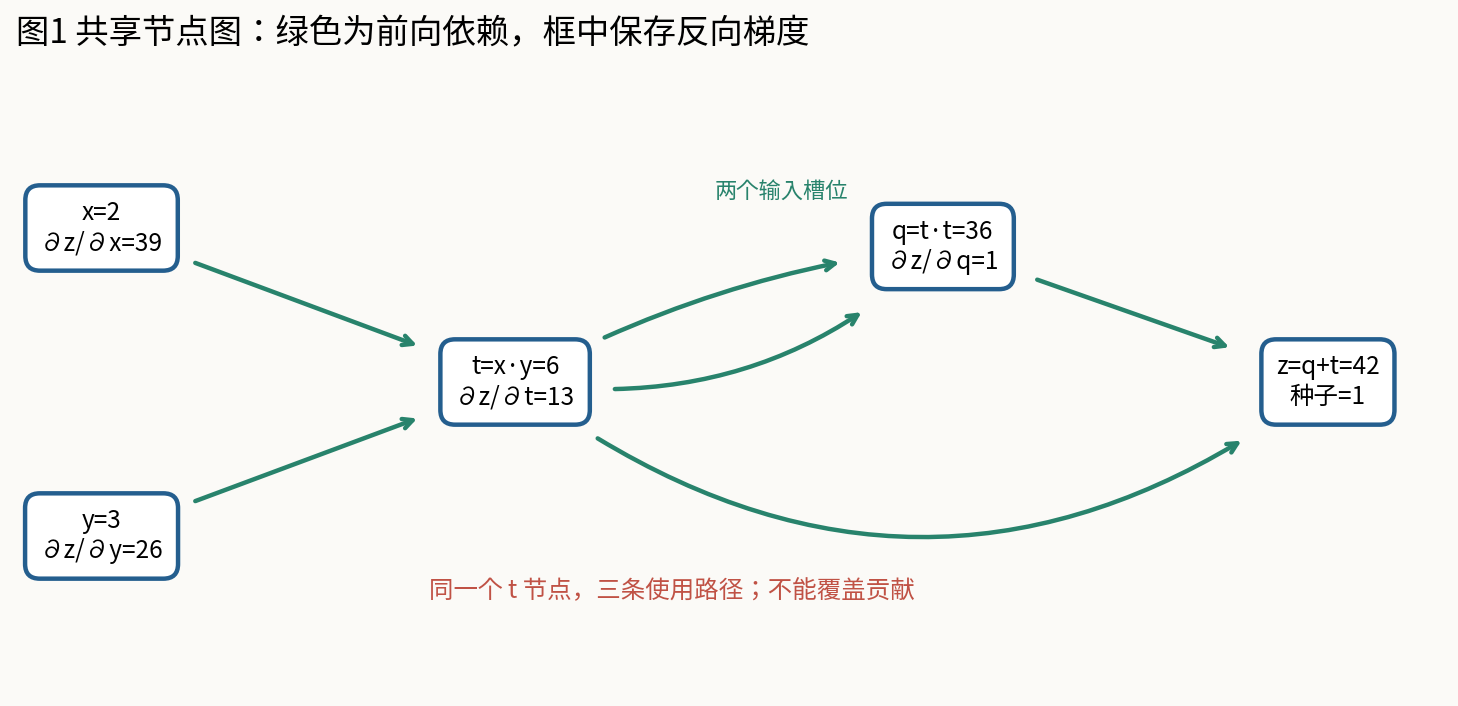

In [3]:
x,y=Value(2,label="x"),Value(3,label="y")
t=x*y;t.label="t"
q=t*t;q.label="q"
z=q+t;z.label="z"
for node in z.backward():
    print(node.label,node.data,node.grad)
print("共享节点梯度必须是13")
display(Image(filename="figures/01_shared_graph.png"))

seed 1 值 12.0 梯度 7.0
seed 1 值 12.0 梯度 7.0
seed 2 值 12.0 梯度 14.0
seed 0 值 12.0 梯度 0.0


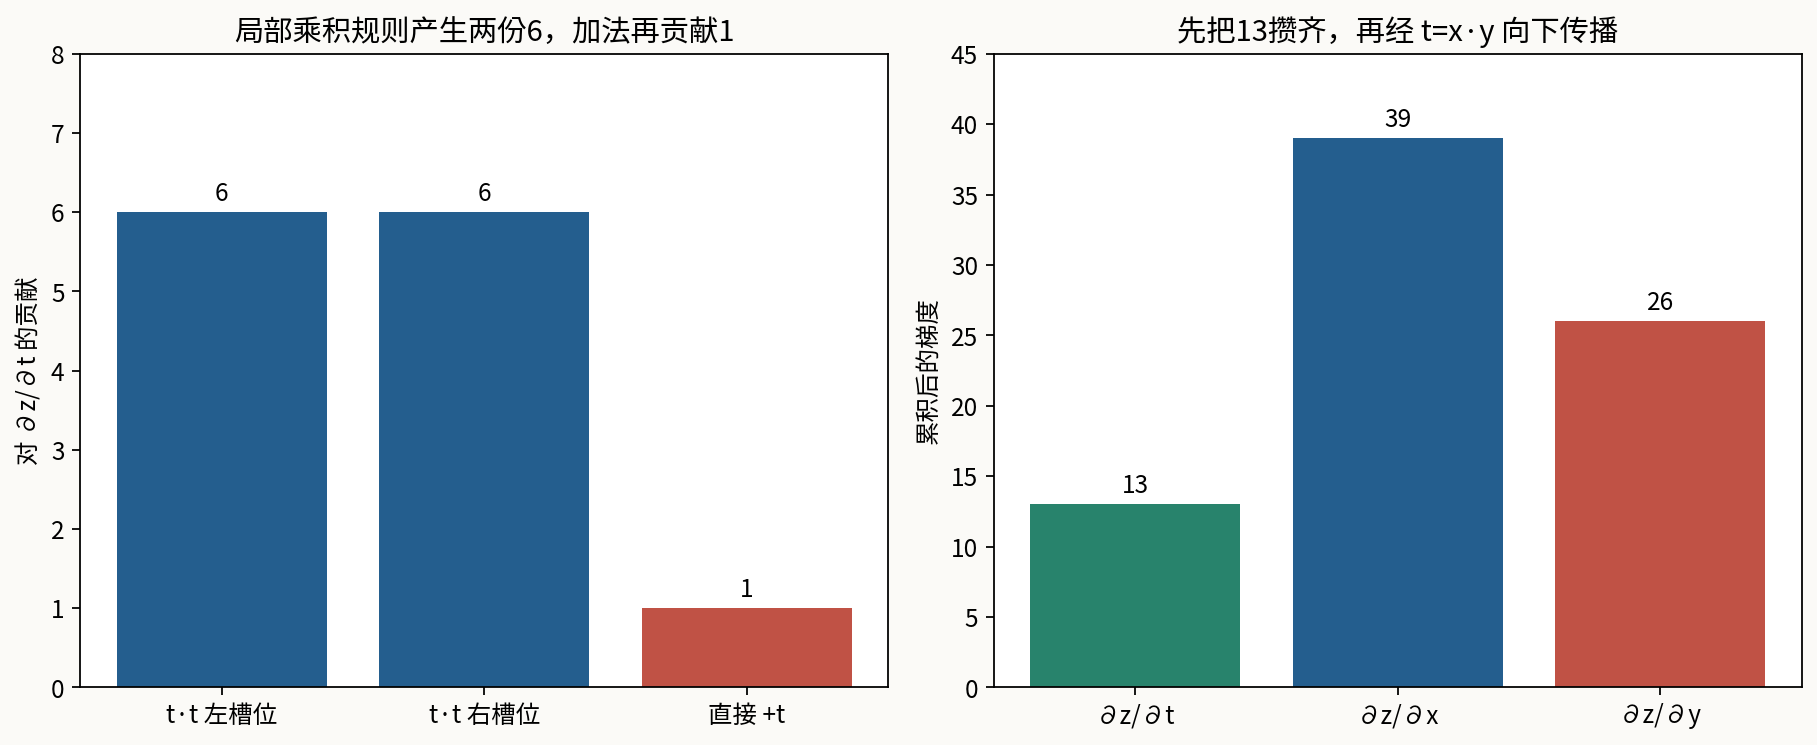

In [4]:
x=Value(3);z=x*x+x
for seed in [1,1,2,0]:
    z.backward(seed);print("seed",seed,"值",z.data,"梯度",x.grad)
display(Image(filename="figures/02_accumulated_paths.png"))

reverse -0.05896849939879192 -0.13106701445828614 0.15186744893974957
forward -0.13106701445828614 0.15186744893974957
finite [-0.13106701446212454, 0.15186744895014093]


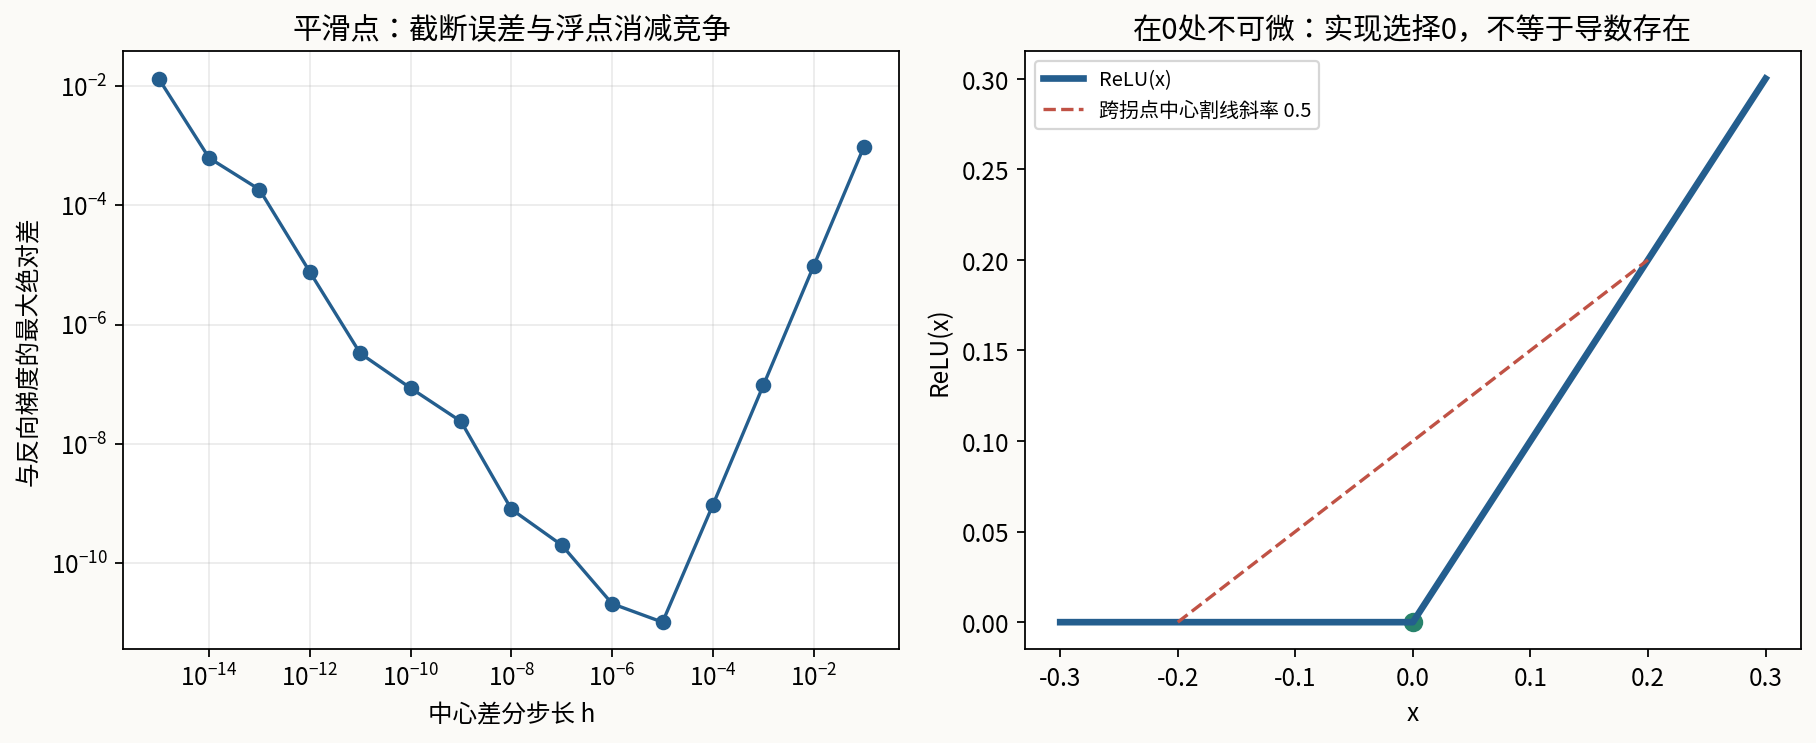

In [5]:
x,y=Value(.7),Value(-1.2)
z=composite(x,y);z.backward()
print("reverse",z.data,x.grad,y.grad)
print("forward",composite(Dual(.7,1),Dual(-1.2,0)).tangent,composite(Dual(.7,0),Dual(-1.2,1)).tangent)
print("finite",finite_difference(composite_float,[.7,-1.2],1e-5))
display(Image(filename="figures/03_gradient_check.png"))

JVP [1.0, 3.0]
VJP列向量 2.0 3.0


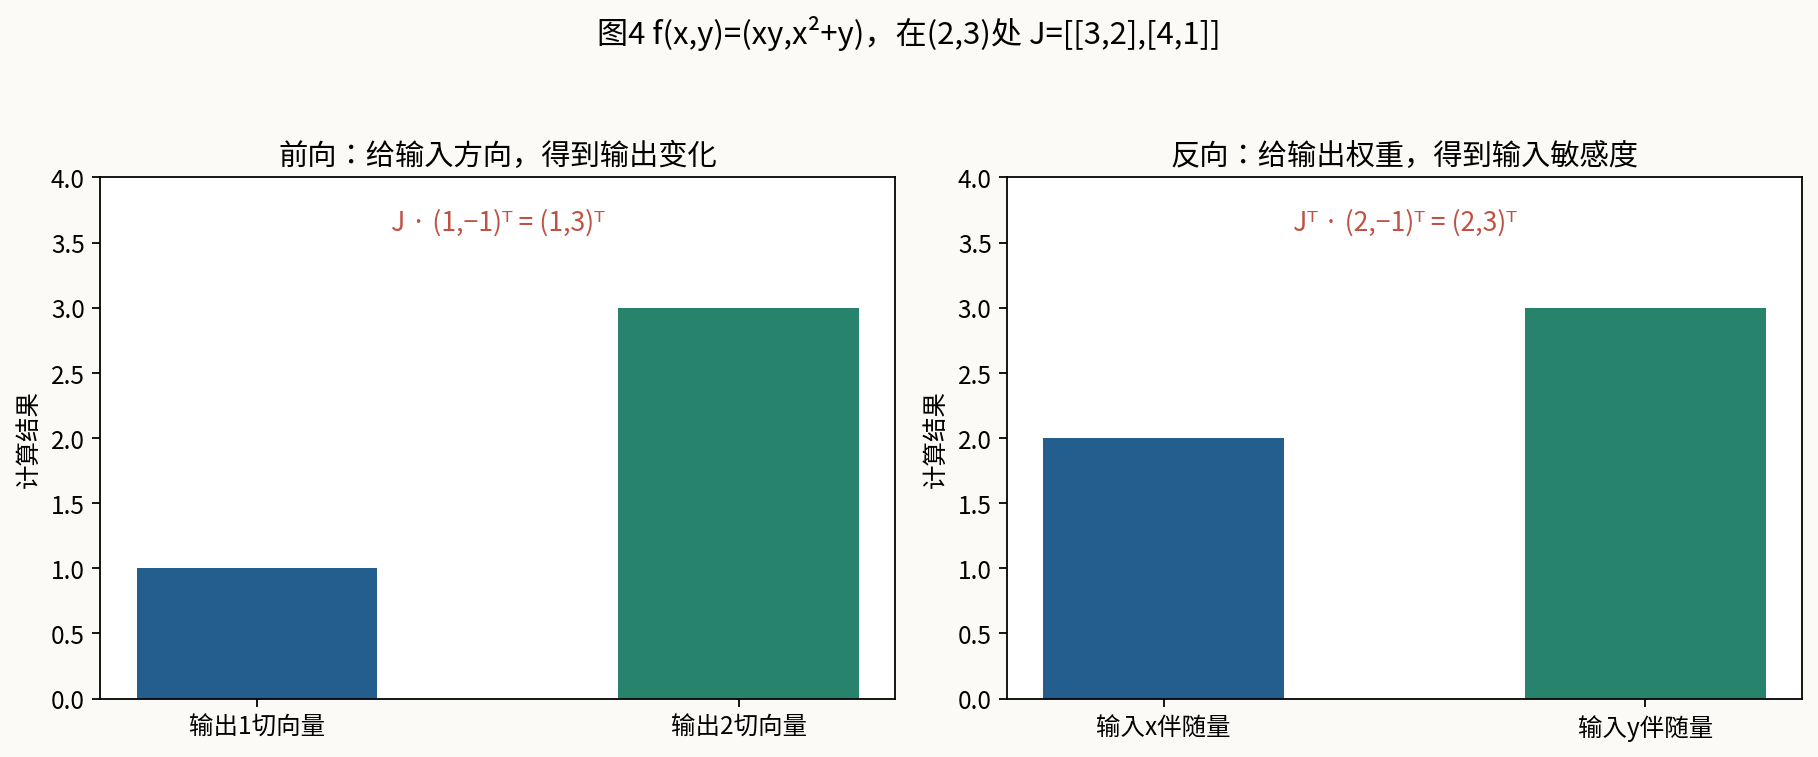

In [6]:
print("JVP",[v.tangent for v in vector_function(Dual(2,1),Dual(3,-1))])
x,y=Value(2),Value(3)
a,b=vector_function(x,y);loss=2*a-b;loss.backward()
print("VJP列向量",x.grad,y.grad)
display(Image(filename="figures/04_jvp_vjp.png"))

In [7]:
x=Value(0);x.relu().backward()
print("ReLU零点选定规则",x.grad,"中心差分",finite_difference(lambda a:max(0.,a),[0.])[0])
print("该点不可微，不应期待两个约定相等")

ReLU零点选定规则 0.0 中心差分 0.5
该点不可微，不应期待两个约定相等


In [8]:
result=run()
print("五点最大差分误差",max(c["max_finite_abs_error"] for c in result["gradient_checks"]))
print("神经元",result["neuron"])
print("步长扫描",result["finite_difference_sweep"])

五点最大差分误差 1.2936851589984144e-10
神经元 {'preactivation': 1.7000000000000002, 'prediction': 1.7000000000000002, 'loss': 0.24500000000000013, 'gradients': {'w1': 1.4000000000000004, 'w2': -0.7000000000000002, 'b': 0.7000000000000002}}
步长扫描 [{'h': 0.1, 'max_abs_error': 0.0009567285332415243}, {'h': 0.01, 'max_abs_error': 9.559072028042515e-06}, {'h': 0.001, 'max_abs_error': 9.558988359192888e-08}, {'h': 0.0001, 'max_abs_error': 9.55815648850944e-10}, {'h': 1e-05, 'max_abs_error': 1.0391354443584078e-11}, {'h': 1e-06, 'max_abs_error': 2.118061281919381e-11}, {'h': 1e-07, 'max_abs_error': 2.0259369182262787e-10}, {'h': 1e-08, 'max_abs_error': 8.087450709126642e-10}, {'h': 1e-09, 'max_abs_error': 2.3864221904146277e-08}, {'h': 1e-10, 'max_abs_error': 8.631426703931133e-08}, {'h': 1e-11, 'max_abs_error': 3.291755536760643e-07}, {'h': 1e-12, 'max_abs_error': 7.591382019889181e-06}, {'h': 1e-13, 'max_abs_error': 0.00018216373411908404}, {'h': 1e-14, 'max_abs_error': 0.0006158090648302472}, {'h': 1

## 独立实现验收
运行真正的unittest测试，不依赖优化模式可能移除的assert。

In [9]:
import unittest
suite=unittest.defaultTestLoader.discover(".", pattern="test_experiment.py")
checks=unittest.TextTestRunner(verbosity=1).run(suite)
if not checks.wasSuccessful():
    raise RuntimeError("unit tests failed")

...................
----------------------------------------------------------------------
Ran 19 tests in 0.005s

OK
